In [1]:
# notebook for testing out new TJ river flow maker...
import sys
import os
import subprocess
import shutil
import numpy as np
import netCDF4 as nc
import matplotlib.pyplot as plt
import gsw
import pickle

from datetime import datetime, timedelta, date

sys.path.append('../sdpm_py_util')
import init_funs_forecast as initfuns
import run_funs as runfuns
import util_functions as utilfuns
import river_functions as riverfuns
import ocn_funs_forecast as ocnfuns
sys.path.append('/home/mspydell/models/PFM_root/PFM/driver')
import driver_functions as driverfuns
#from driver_run_forecast_LV1234 import driver_run_fore_LV1234
from driver_run_pfm_phm import driver_run_pfm_phm


File downloaded successfully: /home/mspydell/research/LV4_river_stuff/IBWC_Qtrje_custom.csv
1 day persistence (Qp) is  2.1103117253170423
climatology is  0.6333004062945081
using cutoff based on std NWM,  =  0.24063059697074218 m3/s
forecasted increased flow, use NWM
plotting river discharge


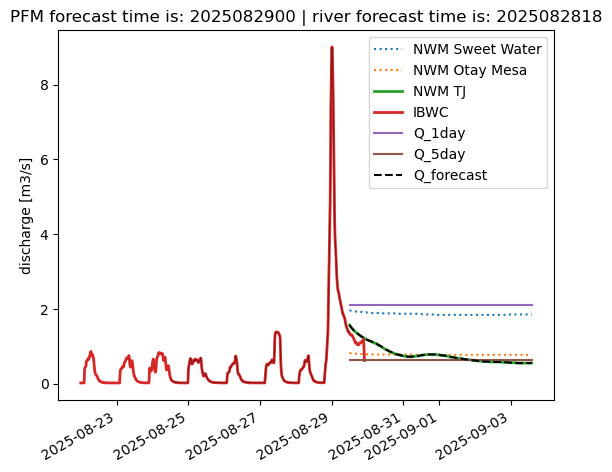

In [2]:
pkl_fnm = "/scratch/PFM_Simulations/forecast_info.pkl"
t,Q = riverfuns.get_forecasted_Q_IBWC(pkl_fnm)
#fig, ax = plt.subplots()
#ax.plot(t,Q)



making river tracer dictionary
making the river discharge pickle file
using the nwm river forecast from the start time:
2025082818
to ensure that the forecast can be found on their server

river discharge data saved as pickle file
loading the river discharge pickle file...
File downloaded successfully: /home/mspydell/research/LV4_river_stuff/IBWC_Qtrje_custom.csv
1 day persistence (Qp) is  0.7861444162720675
climatology is  0.39505437905182583
using cutoff based on std NWM,  =  0.31766086163130236 m3/s
forecasted increased flow, use NWM
plotting river discharge
the time-mean discharge for TJR is 
-0.7614633976141127 m3/s
or  -17.37964058714451 MGD
the time-mean discharge for Sweetwater is 
-1.866016218453888 m3/s
or  -42.58995416999154 MGD
the time-mean discharge for Otay Mesa is 
-0.776504047684432 m3/s
or  -17.72292838434948 MGD
the time-constant discharge for Punta Bandera is 
-2.0 m3/s
or  -45.648 MGD
getting the river temperature. For each river, each time, and depth,
      it is 

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/PFM_Simulations/LV4_Forecast/Forc/LV4_ATM_FORCING.nc'

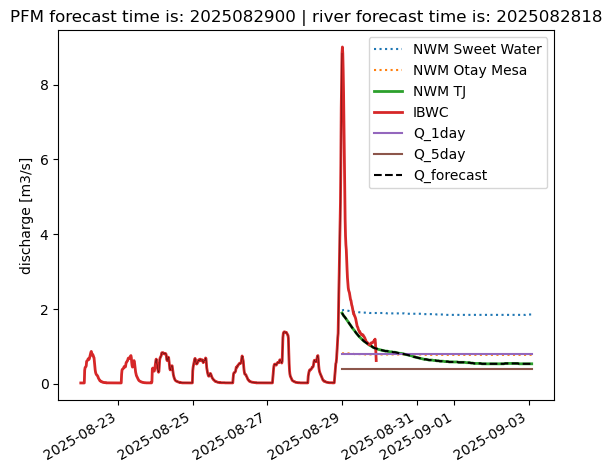

In [3]:
pkl_fnm = "/scratch/PFM_Simulations/forecast_info.pkl"
ocnfuns.mk_lv4_river_nc(pkl_fnm)


File downloaded successfully: /home/mspydell/research/LV4_river_stuff/IBWC_Qtrje_custom.csv
1 day persistence (Qp) is  0.305333404079476
4 day average of all Q<4 (super persistence, Qpp) is  0.27933046371417647
using Q = Qp exp(-t/1.5) + Qpp (1-exp(-t/1.5)) + NWM(t) - NWM(t=0)
plotting river discharge


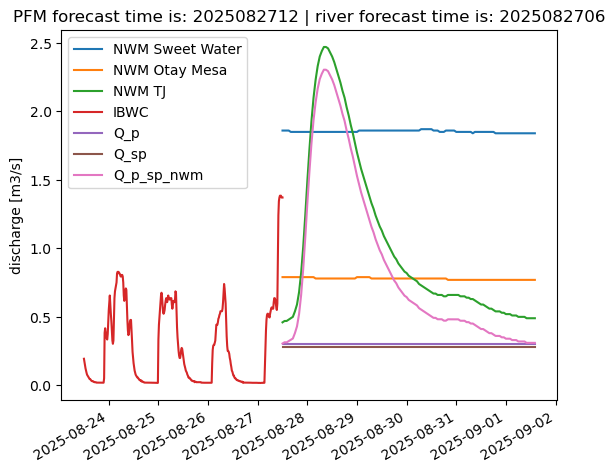

In [2]:
info_pkl="/scratch/matt/PFM_Simulations_v2/forecast_info.pkl"
t,Q = riverfuns.get_forecasted_Q_IBWC(info_pkl)


In [3]:
def get_files_with_full_path(folder_path):
    """
    Returns a list of all files in the given folder with their full paths.

    Args:
        folder_path (str): The path to the folder to scan.

    Returns:
        list: A list of strings, where each string is the full path to a file.
    """
    file_paths = []
    for entry in os.listdir(folder_path):
        full_path = os.path.join(folder_path, entry)
        if os.path.isfile(full_path):
            file_paths.append(full_path)
    return file_paths



In [4]:

# Example usage:
directory_to_scan = "/scratch/PFM_Simulations/cdip_data"  # Replace with the actual path
files_to_copy = get_files_with_full_path(directory_to_scan)
print(files_to_copy)


['/scratch/PFM_Simulations/cdip_data/cdip_1283_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_2235_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1322_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1985_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1061_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1001_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1330_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1041_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_2085_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1306_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1210_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1835_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1735_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1434_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_1161_2025082712.nc', '/scratch/PFM_Simulations/cdip_data/cdip_2385_2025082712.nc', '/scrat

In [5]:

PFM=initfuns.get_model_info(info_pkl)


archive_cdip = 1
PFM['cdip_archive_dir'] = '/dataSIO/PFM_Simulations/Archive/cdip_ncs/'
if archive_cdip == 1:
    print('copying cdip .nc files to archive...')
    dir2 = PFM['cdip_archive_dir']
    for fname in files_to_copy:
        fn_end = os.path.basename(fname)
        fn_2 = dir2 + fn_end
        try:
            shutil.copy(fname, fn_2)
            #print(f"File '{source_file}' copied successfully to '{destination_directory}'")
        except FileNotFoundError:
            print(f"Error: Source file '{fname}' not found.")
        except Exception as e:
            print(f"An error occurred: {e}")


copying cdip .nc files to archive...


In [ ]:


t1_str = '2025-08-14'
t2_str = '2025-08-22'

# if the 1st argument below is False, then we get the most recent 7 days of data
# the last time stamp is about 1-2 hours before current time. Nice!
t,Q = riverfuns.get_observed_TJriver_flow(False,t1_str,t2_str)





2025-08-22 18:00:00


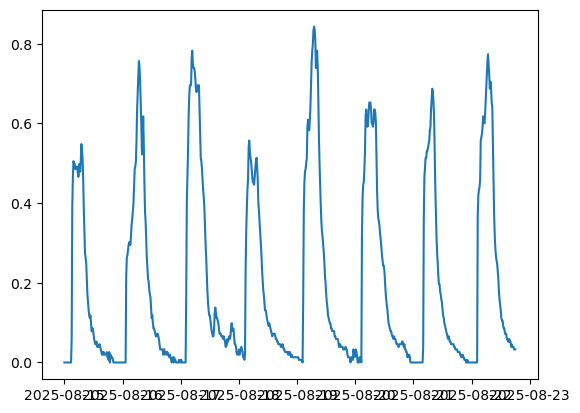

In [ ]:
fig, ax = plt.subplots()
print(t[-1])
ax.plot(t,Q)


In [9]:
file_in = '/scratch/PFM_Simulations/LV4_Forecast/Forc/river_Q.pkl'
with open(file_in,'rb') as fp:
    NWM = pickle.load(fp)

t_nwm = NWM['time']
q_nwm = NWM['discharge'][:,2]


In [38]:
#t_fore = t_nwm[0]
tf_dt = t_nwm[0] #datetime.strptime(t_fore,'%Y%m%d%H')
start_time = tf_dt - 1* timedelta(days=1)
end_time = tf_dt

# Create a boolean mask
# This directly compares datetime objects within the array
mask = (t >= start_time) & (t <= end_time)

    # Get the indices where the mask is True
indices = np.where(mask)[0]
    # take the mean over these indices
Qb1 = np.mean( Q[indices] )

mask2 = (Q<1.0)
i2 = np.where(mask2)[0]
Qb2 = np.mean( Q[i2] )

print(Qb1)
print(Qb2)

Qf_p = Qb1*np.ones(np.shape(t_nwm))
#print(np.shape(q_nwm))
#print(np.shape(Qf_p))
Qf_pnwm = Qf_p[:,0] + q_nwm - q_nwm[0]
dt = t_nwm - t_nwm[0]
dt_sec = []
for dtt in dt:
    dt_sec.append(dtt[0].total_seconds())
dt_day = np.array(dt_sec) / 3600 /24
tau_day = 1.5
alpha = np.exp(-dt_day / tau_day)
Q_new2 = Qf_p[:,0] * alpha + (1-alpha)*Qb2 
Q_new = Qf_p[:,0] * alpha + (1-alpha)*Qb2 + q_nwm - q_nwm[0]




0.16465141780116258
0.20513315114146208


2025-08-22 18:00:00


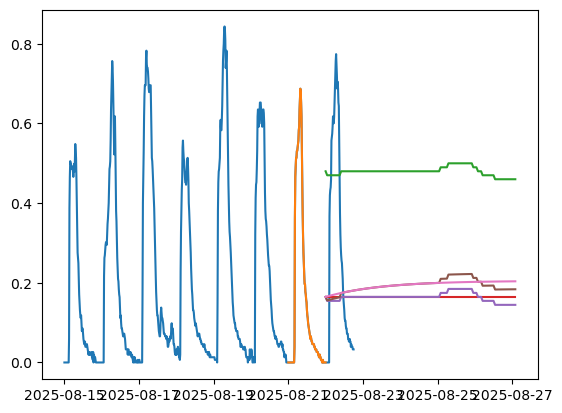

In [39]:
fig, ax = plt.subplots()
print(t[-1])
ax.plot(t,Q)
ax.plot(t[indices],Q[indices])
ax.plot(t_nwm,q_nwm)
ax.plot(t_nwm,Qf_p)
ax.plot(t_nwm,Qf_pnwm)
ax.plot(t_nwm,Q_new)
ax.plot(t_nwm,Q_new2)



In [4]:
fn = '/scratch/PFM_Simulations/LV4_Forecast/Forc/LV4_river.nc'
ds=nc.Dataset(fn)


(123, 10, 9)
[-- -- -- -- -- -- -- -- --]


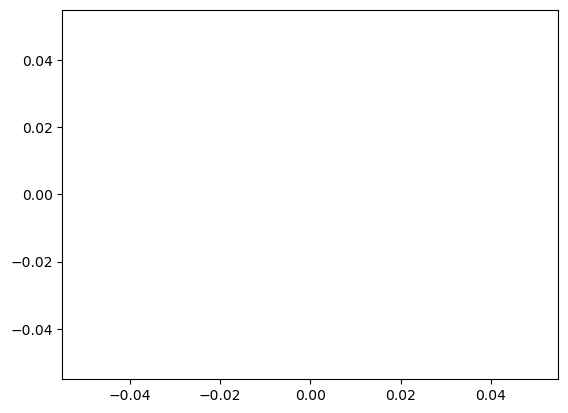

In [9]:
fig, ax = plt.subplots()
dye_02 = ds.variables['river_dye_02'][:]
Qtj = ds.variables['river_transport'][:,0]
print(np.shape(dye_02))
print(Qtj[1:10])
#ax.plot(dye_02[:,-1,0])
ax.plot(Qtj)


In [ ]:

yyyymmdd = '20250827'
info_pkl="/scratch/matt/PFM_Simulations_v2/forecast_info.pkl"
ocnfuns.get_hycom_data_1hr_v2(yyyymmdd,info_pkl)